In [1]:
# ====================
# 📊 Customer Churn — Exploratory Data Analysis (EDA)
# ====================
# Author: Alee Chihaoui
# Date: June 2026

# Standard data science imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for prettier output
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)
sns.set_style("whitegrid")  # Clean seaborn style
plt.rcParams['figure.figsize'] = (10, 6)  # Default figure size

# Display all outputs in a cell (not just the last one)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

print("📦 Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


📦 Libraries loaded successfully
Pandas version: 2.2.0
NumPy version: 1.26.0


In [2]:
# ====================
# 📥 Load the dataset
# ====================

# Path to the raw data file (relative to notebook location)
DATA_PATH = "../data/raw/telco_churn.csv"

# Load with pandas
df = pd.read_csv(DATA_PATH)

# Confirm it loaded
print(f"✅ Dataset loaded successfully")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully
📊 Shape: 7,043 rows × 21 columns


In [3]:
# ====================
# 👀 First glimpse of the data
# ====================

# Show the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ====================
# 📋 What columns do we have?
# ====================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# ====================
# 🔍 Investigate TotalCharges
# ====================

# What does TotalCharges look like?
print("First 5 values of TotalCharges:")
print(df['TotalCharges'].head())

print("\n" + "="*50)
print("Trying to convert TotalCharges to numeric...")

# Try to convert to float (errors='coerce' turns failures into NaN)
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# How many values FAILED to convert?
n_failed = df['TotalCharges_numeric'].isna().sum()
print(f"\n❌ Number of values that couldn't be converted: {n_failed}")
print(f"📊 That's {n_failed/len(df)*100:.2f}% of the dataset")

First 5 values of TotalCharges:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

Trying to convert TotalCharges to numeric...

❌ Number of values that couldn't be converted: 11
📊 That's 0.16% of the dataset


In [6]:
# Show the rows that have problematic TotalCharges
problematic_rows = df[df['TotalCharges_numeric'].isna()]
print(f"Found {len(problematic_rows)} problematic rows:\n")

# Display some key columns to understand WHY they're broken
problematic_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Found 11 problematic rows:



,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [7]:
# ====================
# 🧹 Clean TotalCharges
# ====================

# Step 1: Convert to numeric (this creates NaN for the 11 problematic values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Fill the NaN values with 0 (new customers = no charges yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Drop our temporary investigation column
df = df.drop(columns=['TotalCharges_numeric'])

# Step 4: Verify the fix worked
print("✅ TotalCharges cleaned!")
print(f"📊 New dtype: {df['TotalCharges'].dtype}")
print(f"❌ Remaining NaN values: {df['TotalCharges'].isna().sum()}")
print(f"\nVerification — the 11 previously broken rows now show:")

# Show the same 11 rows again to confirm
df.loc[[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], 
       ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

✅ TotalCharges cleaned!
📊 New dtype: float64
❌ Remaining NaN values: 0

Verification — the 11 previously broken rows now show:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [8]:
# ====================
# 🔎 Final data quality check
# ====================

# Are there any other missing values we missed?
print("Missing values per column:")
print(df.isna().sum())

print("\n" + "="*50)
print("\n📊 Updated column types:")
print(df.dtypes)

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


📊 Updated column types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     obj

In [9]:
# ====================
# 🎯 Target variable distribution — Version 1: Basic
# ====================

# Count how many Yes vs No
churn_counts = df['Churn'].value_counts()
print("Churn distribution:")
print(churn_counts)
print()
print("Churn rate (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


<Axes: xlabel='Churn'>

Text(0, 5224, '5,174\n(73.5%)')

Text(1, 1919, '1,869\n(26.5%)')

Text(0.5, 1.0, 'Customer Churn Distribution')

Text(0.5, 0, 'Churn Status')

Text(0, 0.5, 'Number of Customers')

[Text(0, 0, 'Stayed'), Text(1, 0, 'Churned')]

Text(0.98, 0.95, 'Total: 7,043 customers')

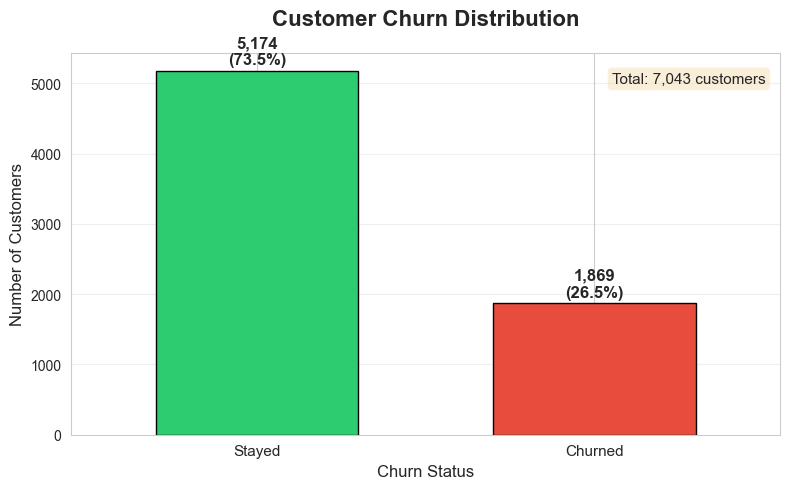

✅ Chart saved to reports/figures/01_churn_distribution.png


In [10]:
# ====================
# 🎯 Target variable distribution — Version 2: Bar chart
# ====================

fig, ax = plt.subplots(figsize=(8, 5))

# Create the bar chart
churn_counts.plot(kind='bar', 
                  ax=ax, 
                  color=['#2ecc71', '#e74c3c'],  # Green for stayers, red for churners
                  edgecolor='black',
                  width=0.6)

# Add value labels on top of each bar
for i, value in enumerate(churn_counts.values):
    percentage = value / len(df) * 100
    ax.text(i, value + 50, f'{value:,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Beautify
ax.set_title('Customer Churn Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Churn Status', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Stayed', 'Churned'], rotation=0, fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add total customers annotation
ax.text(0.98, 0.95, f'Total: {len(df):,} customers', 
        transform=ax.transAxes, fontsize=11, 
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../reports/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to reports/figures/01_churn_distribution.png")

<Axes: xlabel='Churn'>

Text(0, 5224, '5,174\n(73.5%)')

Text(1, 1919, '1,869\n(26.5%)')

Text(0.5, 1.0, 'Customer Count by Churn Status')

Text(0.5, 0, '')

Text(0, 0.5, 'Number of Customers')

[Text(0, 0, 'Stayed'), Text(1, 0, 'Churned')]

Text(0.5, 1.0, 'Churn Rate Proportion')

Text(0.5, 1.02, '🎯 Target Variable Analysis: Customer Churn')

C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\3590352863.py:48: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\3590352863.py:49: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig('../reports/figures/02_churn_distribution_dashboard.png',
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


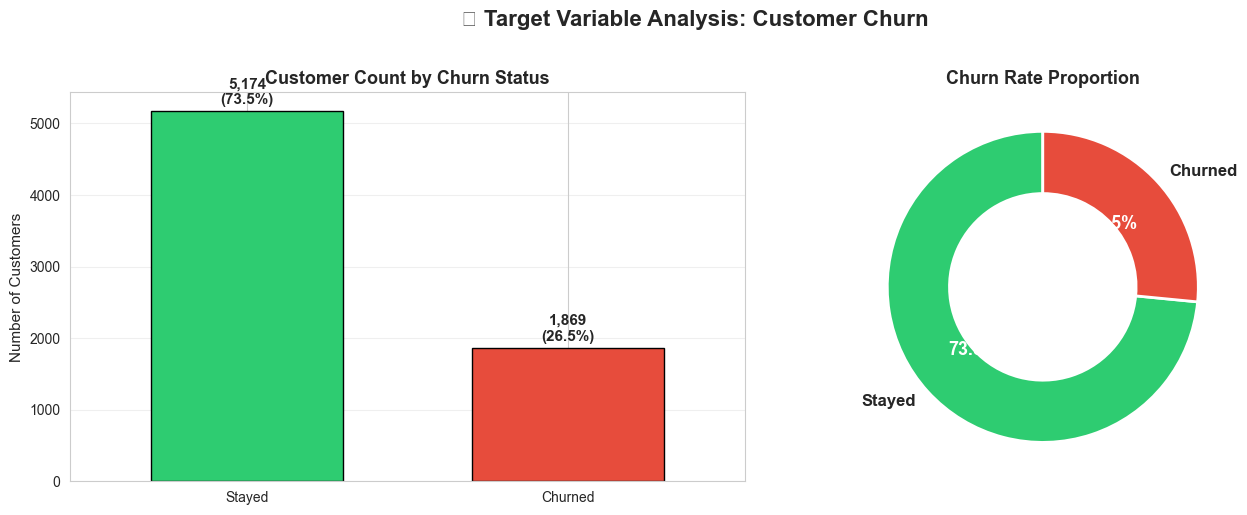


📊 KEY INSIGHTS
Total customers in dataset: 7,043
Customers who stayed:       5,174 (73.5%)
Customers who churned:      1,869 (26.5%)

💡 Churn rate of 26.5% is HIGH for telecom industry
   (industry average is ~10-15%). This represents a real business problem.

⚠️  Class imbalance ratio: 2.8:1
   → We'll need to handle this during model training.


In [11]:
# ====================
# 🎯 Target variable distribution — Version 3: Dashboard-style
# ====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === LEFT: Bar chart ===
churn_counts.plot(kind='bar', 
                  ax=axes[0], 
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='black', 
                  width=0.6)

for i, value in enumerate(churn_counts.values):
    percentage = value / len(df) * 100
    axes[0].text(i, value + 50, f'{value:,}\n({percentage:.1f}%)', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# === RIGHT: Donut chart ===
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, 
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Make percentage labels white inside the donut
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)

axes[1].set_title('Churn Rate Proportion', fontsize=13, fontweight='bold')

# Main title for the whole figure
fig.suptitle('🎯 Target Variable Analysis: Customer Churn', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../reports/figures/02_churn_distribution_dashboard.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print a business insight summary
print("\n" + "="*60)
print("📊 KEY INSIGHTS")
print("="*60)
print(f"Total customers in dataset: {len(df):,}")
print(f"Customers who stayed:       {churn_counts['No']:,} ({churn_counts['No']/len(df)*100:.1f}%)")
print(f"Customers who churned:      {churn_counts['Yes']:,} ({churn_counts['Yes']/len(df)*100:.1f}%)")
print(f"\n💡 Churn rate of {churn_counts['Yes']/len(df)*100:.1f}% is HIGH for telecom industry")
print(f"   (industry average is ~10-15%). This represents a real business problem.")
print(f"\n⚠️  Class imbalance ratio: {churn_counts['No']/churn_counts['Yes']:.1f}:1")
print(f"   → We'll need to handle this during model training.")

In [12]:
# ====================
# 🛠️ Helper function for categorical analysis
# ====================

def plot_categorical_vs_churn(feature, df=df, figsize=(14, 5)):
    """
    Plot the relationship between a categorical feature and Churn.
    Creates two side-by-side charts:
    1. Count of customers per category, split by Churn status
    2. Churn rate (%) per category
    
    Parameters
    ----------
    feature : str
        Name of the categorical column to analyze
    df : pd.DataFrame
        The dataset
    figsize : tuple
        Figure dimensions
    """
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # === LEFT: Count plot ===
    sns.countplot(data=df, x=feature, hue='Churn', 
                  ax=axes[0], 
                  palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
                  edgecolor='black')
    axes[0].set_title(f'Customer Count by {feature}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(feature, fontsize=11)
    axes[0].set_ylabel('Number of Customers', fontsize=11)
    axes[0].legend(title='Churn', loc='upper right')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Rotate x labels if there are many categories
    if df[feature].nunique() > 3:
        axes[0].tick_params(axis='x', rotation=30)
    
    # === RIGHT: Churn rate (%) per category ===
    churn_rate = df.groupby(feature)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    bars = axes[1].bar(churn_rate.index.astype(str), churn_rate.values, 
                        color='#e74c3c', edgecolor='black', alpha=0.8)
    
    # Add value labels on top of bars
    for bar, value in zip(bars, churn_rate.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.5, 
                     f'{value:.1f}%', ha='center', va='bottom', 
                     fontsize=11, fontweight='bold')
    
    # Add baseline (overall churn rate)
    overall_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
    axes[1].axhline(y=overall_rate, color='blue', linestyle='--', 
                    linewidth=2, label=f'Overall avg: {overall_rate:.1f}%')
    
    axes[1].set_title(f'Churn Rate (%) by {feature}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(feature, fontsize=11)
    axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
    axes[1].legend(loc='upper right')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, max(churn_rate.values) * 1.2)
    
    if df[feature].nunique() > 3:
        axes[1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()
    
    # Print the data behind the chart
    print(f"\n📊 Churn rate by {feature}:")
    for category, rate in churn_rate.items():
        diff = rate - overall_rate
        sign = "⬆️" if diff > 0 else "⬇️"
        print(f"  {category}: {rate:.1f}% {sign} ({diff:+.1f}% vs overall)")

print("✅ Function defined. Ready to analyze any categorical feature!")

✅ Function defined. Ready to analyze any categorical feature!


C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


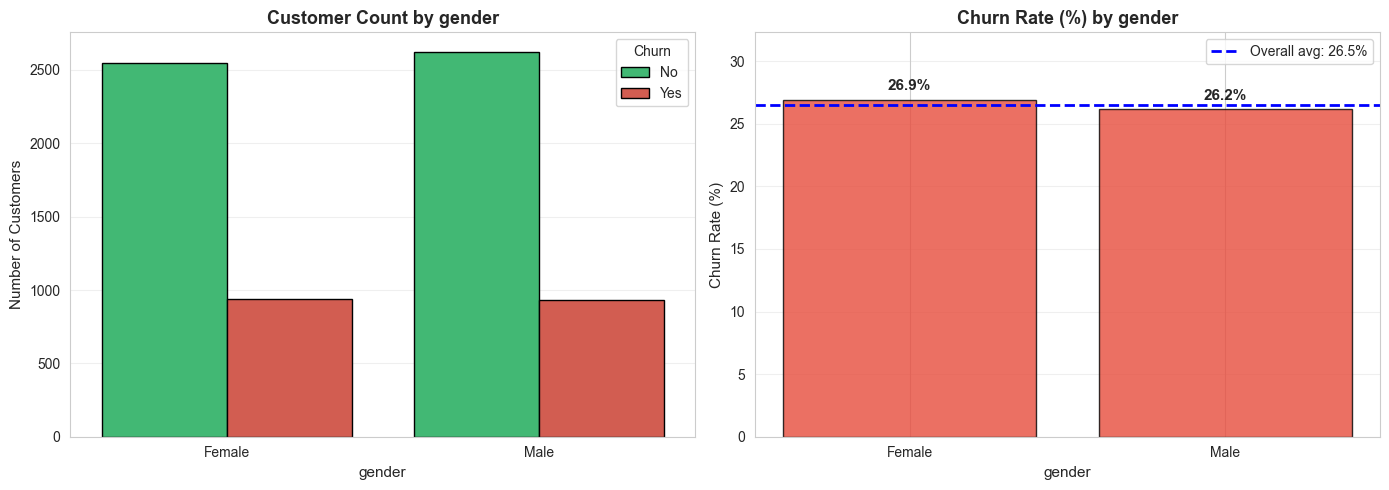


📊 Churn rate by gender:
  Female: 26.9% ⬆️ (+0.4% vs overall)
  Male: 26.2% ⬇️ (-0.4% vs overall)


In [13]:
# 🔬 Insight #1: Gender
plot_categorical_vs_churn('gender')

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


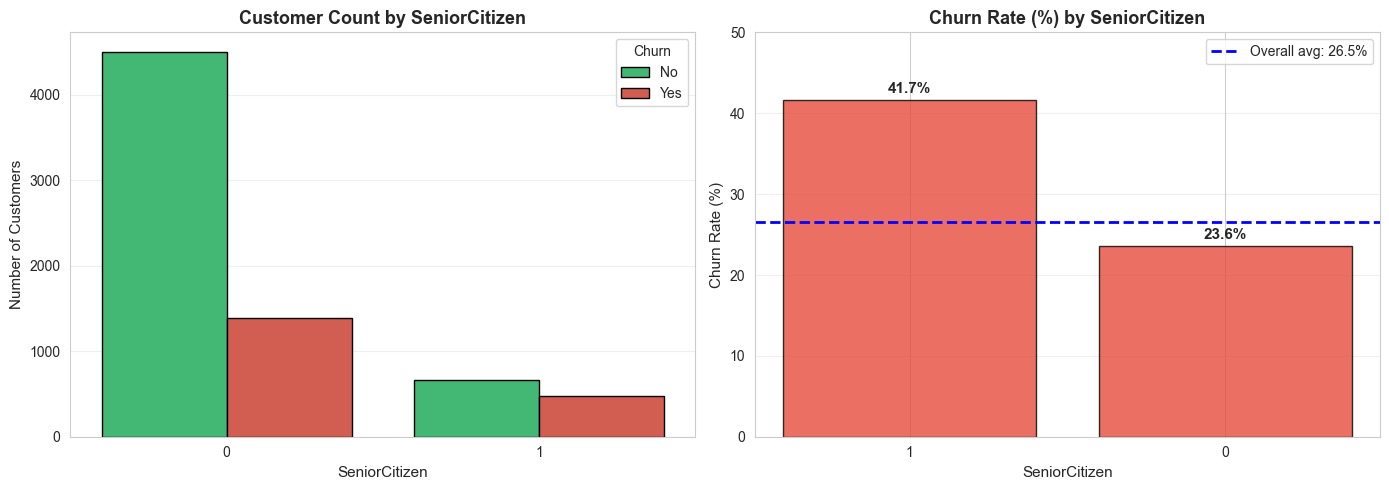


📊 Churn rate by SeniorCitizen:
  1: 41.7% ⬆️ (+15.1% vs overall)
  0: 23.6% ⬇️ (-2.9% vs overall)


In [14]:
# 🔬 Insight #2: Senior citizens
plot_categorical_vs_churn('SeniorCitizen')

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


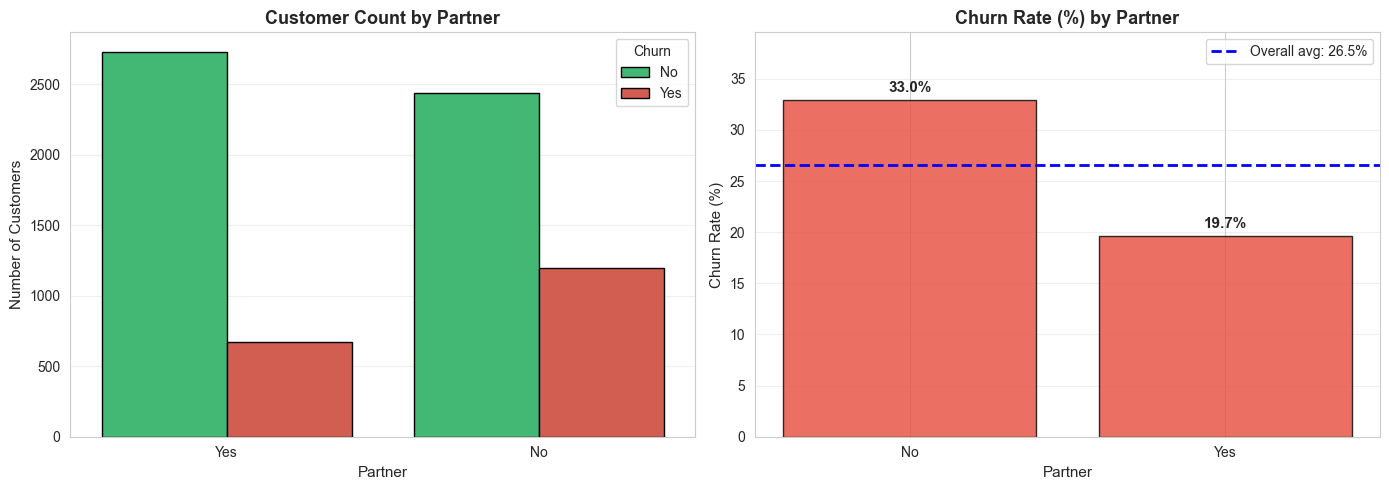


📊 Churn rate by Partner:
  No: 33.0% ⬆️ (+6.4% vs overall)
  Yes: 19.7% ⬇️ (-6.9% vs overall)




C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


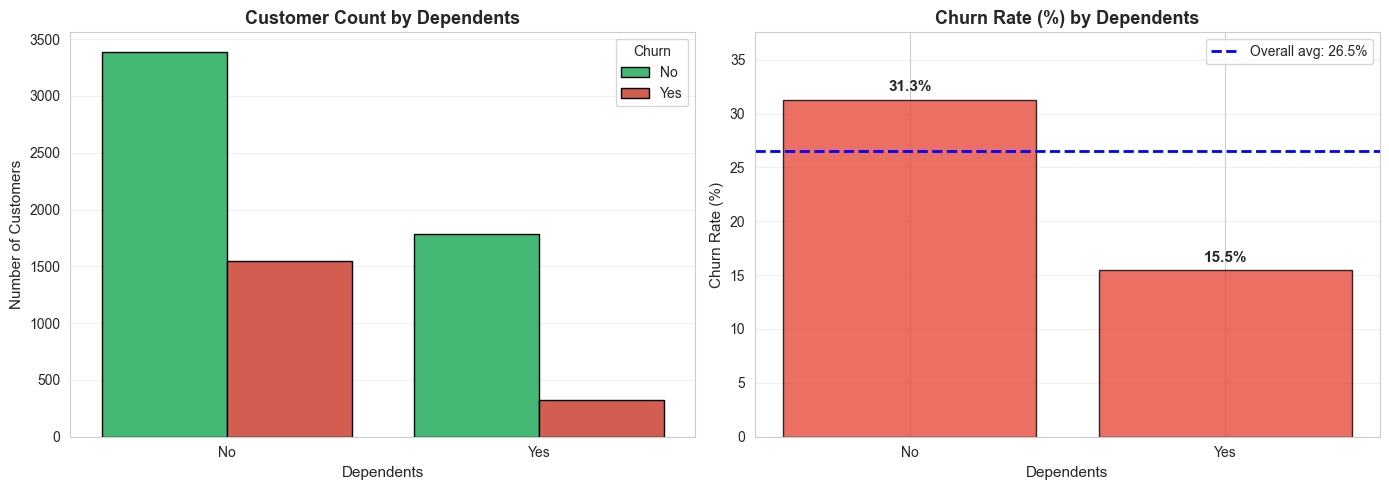


📊 Churn rate by Dependents:
  No: 31.3% ⬆️ (+4.7% vs overall)
  Yes: 15.5% ⬇️ (-11.1% vs overall)


In [15]:
# 🔬 Insight #3: Family situation
plot_categorical_vs_churn('Partner')
print("\n" + "="*60 + "\n")
plot_categorical_vs_churn('Dependents')

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


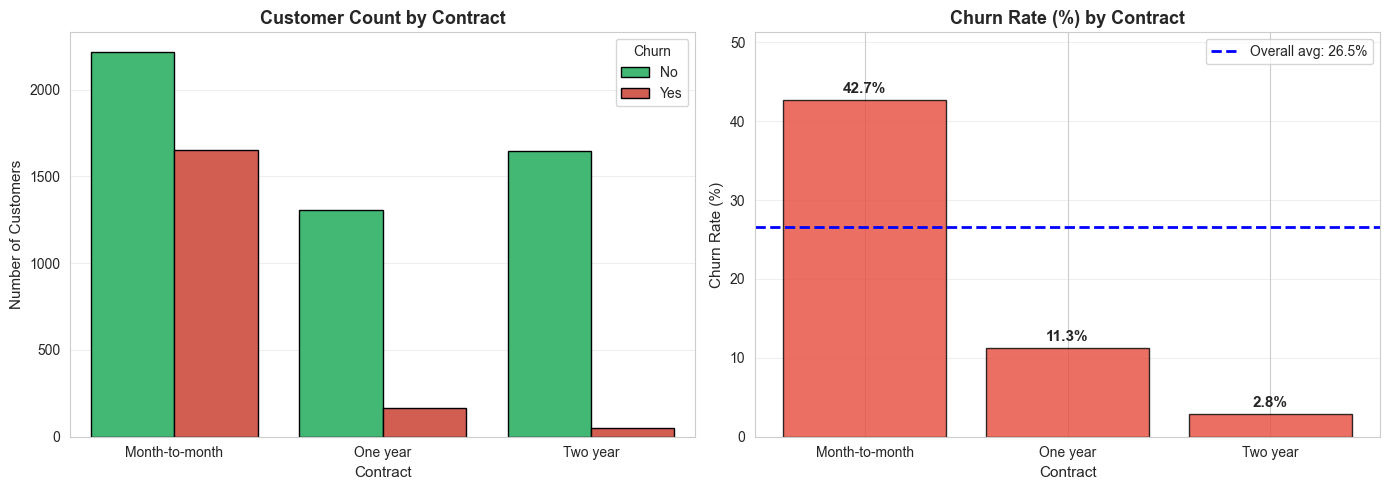


📊 Churn rate by Contract:
  Month-to-month: 42.7% ⬆️ (+16.2% vs overall)
  One year: 11.3% ⬇️ (-15.3% vs overall)
  Two year: 2.8% ⬇️ (-23.7% vs overall)


In [16]:
# 🔬 Insight #4: Contract type (the BIG one)
plot_categorical_vs_churn('Contract')

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


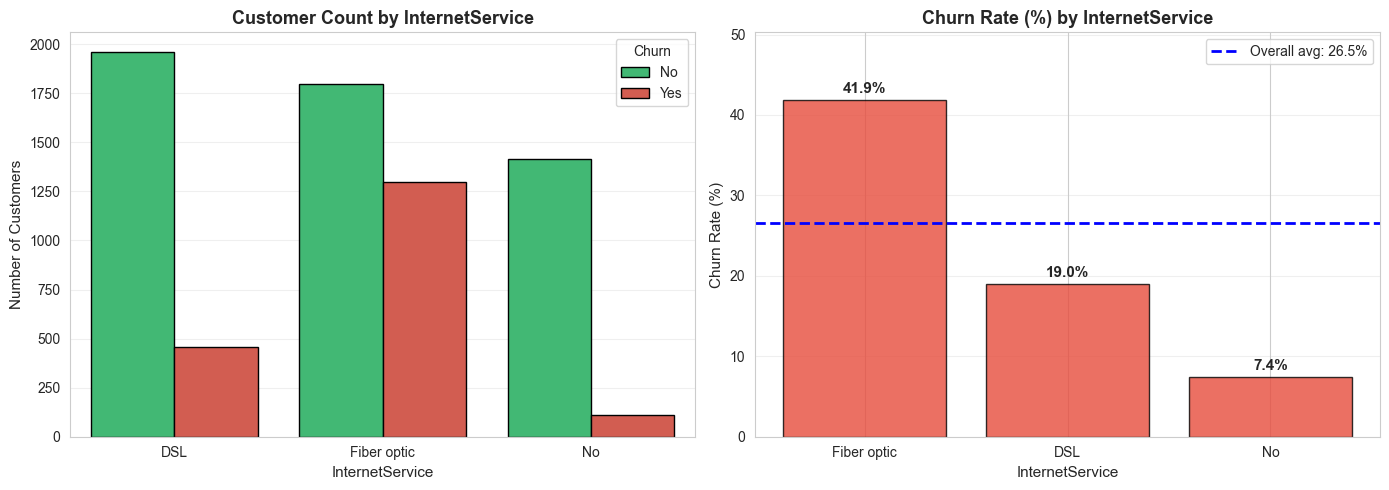


📊 Churn rate by InternetService:
  Fiber optic: 41.9% ⬆️ (+15.4% vs overall)
  DSL: 19.0% ⬇️ (-7.6% vs overall)
  No: 7.4% ⬇️ (-19.1% vs overall)


In [17]:
# 🔬 Insight #5: Internet service
plot_categorical_vs_churn('InternetService')

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


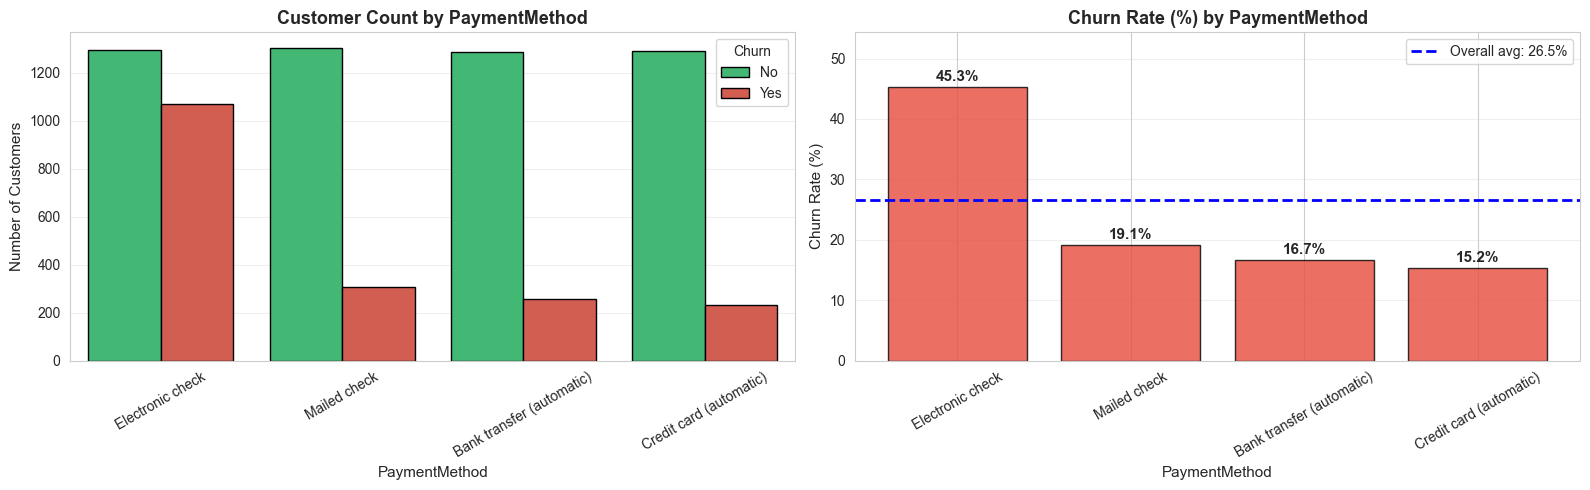


📊 Churn rate by PaymentMethod:
  Electronic check: 45.3% ⬆️ (+18.7% vs overall)
  Mailed check: 19.1% ⬇️ (-7.4% vs overall)
  Bank transfer (automatic): 16.7% ⬇️ (-9.8% vs overall)
  Credit card (automatic): 15.2% ⬇️ (-11.3% vs overall)


In [18]:
# 🔬 Insight #6: Payment method
plot_categorical_vs_churn('PaymentMethod', figsize=(16, 5))

In [19]:
# 🔬 Insight #7: Service add-ons (batch analysis)
service_features = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

# Calculate churn rate for each service feature
print("📊 Impact of add-on services on churn rate:\n")
print(f"{'Service':<25} {'No':<15} {'Yes':<15} {'Difference'}")
print("-" * 75)

for service in service_features:
    churn_by_service = df.groupby(service)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    )
    
    if 'No' in churn_by_service.index and 'Yes' in churn_by_service.index:
        no_rate = churn_by_service['No']
        yes_rate = churn_by_service['Yes']
        diff = yes_rate - no_rate
        emoji = "🛡️" if diff < -10 else "⚠️" if diff > 5 else "➡️"
        print(f"{emoji} {service:<22} {no_rate:>5.1f}%         {yes_rate:>5.1f}%         {diff:+.1f}%")

📊 Impact of add-on services on churn rate:

Service                   No              Yes             Difference
---------------------------------------------------------------------------
🛡️ OnlineSecurity          41.8%          14.6%         -27.2%
🛡️ OnlineBackup            39.9%          21.5%         -18.4%
🛡️ DeviceProtection        39.1%          22.5%         -16.6%
🛡️ TechSupport             41.6%          15.2%         -26.5%
➡️ StreamingTV             33.5%          30.1%         -3.5%
➡️ StreamingMovies         33.7%          29.9%         -3.7%


Text(0.0, 42.26672384219554, '41.8%')

Text(1.0, 15.111193660227837, '14.6%')

Text(2.0, 7.904980340760157, '7.4%')

Text(0.5, 1.0, 'OnlineSecurity')

Text(0, 0.5, 'Churn Rate (%)')

...

Text(0.5, 1.0, 'StreamingMovies')

Text(0, 0.5, 'Churn Rate (%)')

(0.0, 50.0)

Text(0.5, 1.0, '🛡️ Impact of Add-on Services on Customer Churn')

C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\727101518.py:29: UserWarning: Glyph 128737 (\N{SHIELD}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\727101518.py:29: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\727101518.py:30: UserWarning: Glyph 128737 (\N{SHIELD}) missing from current font.
  plt.savefig('../reports/figures/03_services_impact.png', dpi=150, bbox_inches='tight')
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\727101518.py:30: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.savefig('../reports/figures/03_services_impact.png', dpi=150, bbox_inches='tight')
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\aleec\anacond

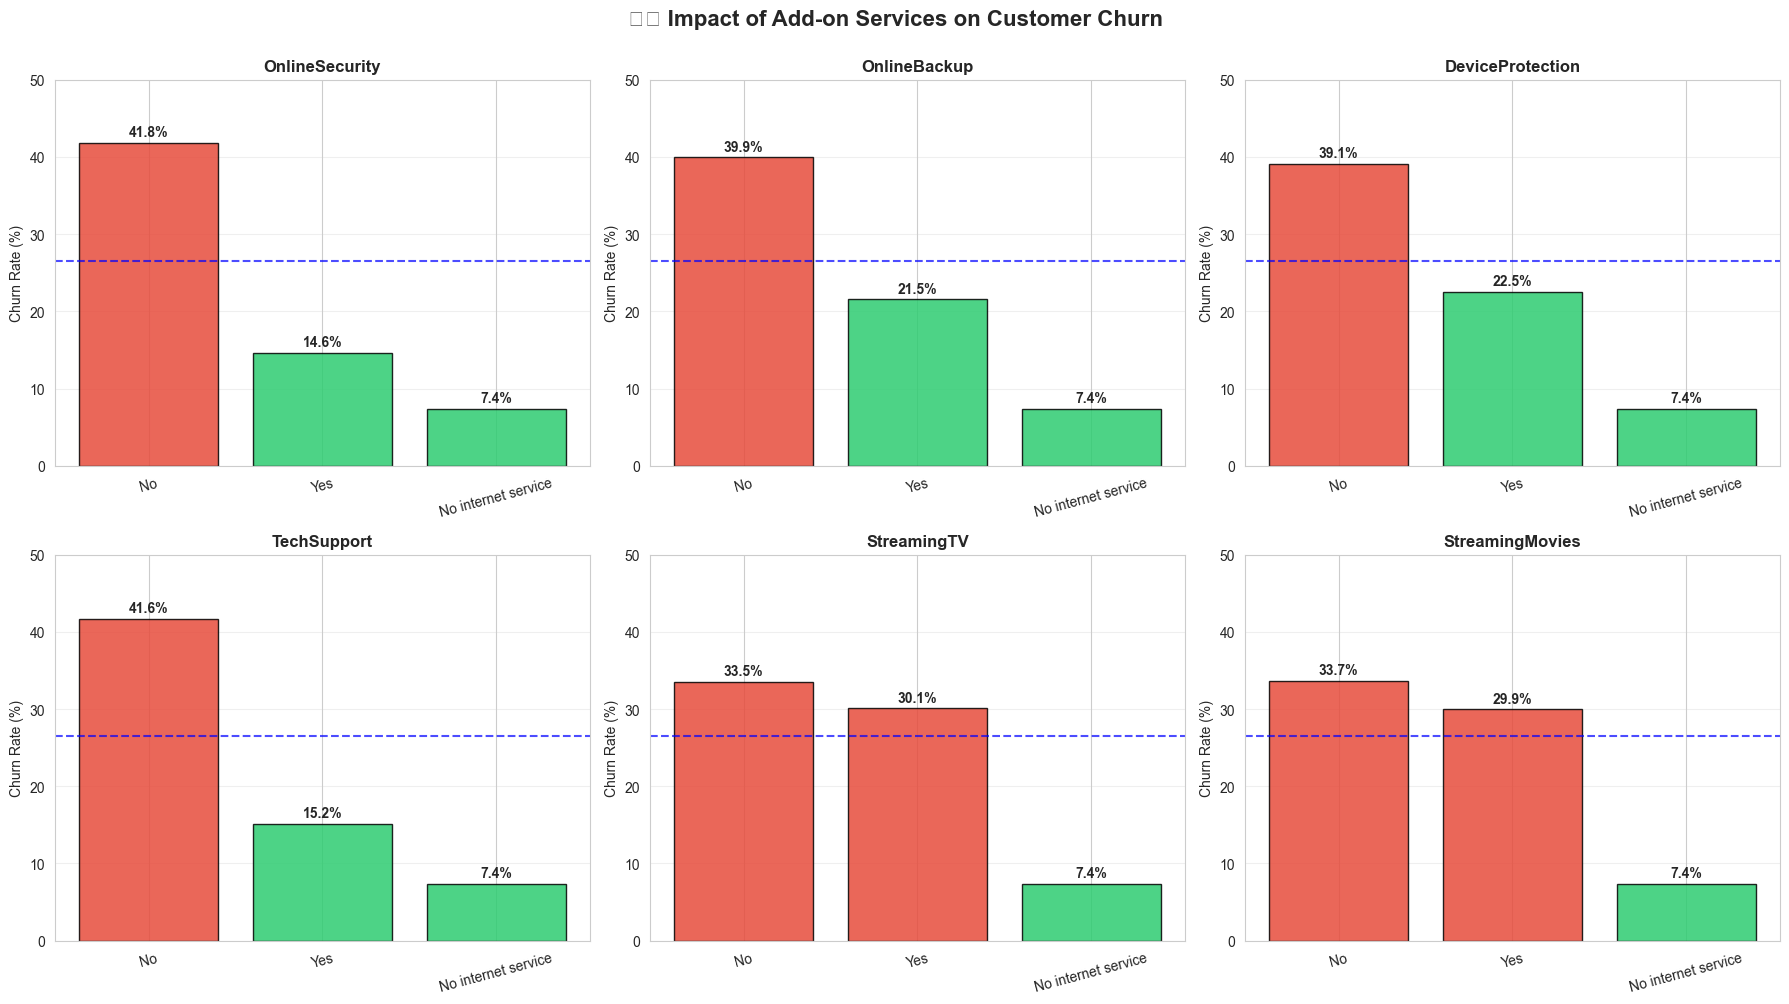

✅ Chart saved!


In [20]:
# 🎨 Visualize all service features in one chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, service in enumerate(service_features):
    churn_rate = df.groupby(service)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    colors_list = ['#e74c3c' if r > 26.5 else '#2ecc71' for r in churn_rate.values]
    
    bars = axes[idx].bar(churn_rate.index.astype(str), churn_rate.values, 
                          color=colors_list, edgecolor='black', alpha=0.85)
    
    for bar, value in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, value + 0.5, 
                       f'{value:.1f}%', ha='center', va='bottom', 
                       fontsize=10, fontweight='bold')
    
    axes[idx].axhline(y=26.5, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[idx].set_title(f'{service}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylim(0, 50)
    axes[idx].tick_params(axis='x', rotation=15)

fig.suptitle('🛡️ Impact of Add-on Services on Customer Churn', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../reports/figures/03_services_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")

In [21]:
# ====================
# 🛠️ Helper function for numerical analysis
# ====================

def plot_numerical_vs_churn(feature, df=df, figsize=(16, 5)):
    """
    Analyze a numerical feature's relationship with Churn.
    Creates three side-by-side charts:
    1. Histogram with KDE — distribution comparison
    2. Boxplot — quartiles and outliers comparison
    3. Mean comparison — bar chart of average values
    """
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    palette = {'No': '#2ecc71', 'Yes': '#e74c3c'}
    
    # === LEFT: Histogram + KDE ===
    for status in ['No', 'Yes']:
        subset = df[df['Churn'] == status][feature]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f'Churn={status}',
                     color=palette[status], edgecolor='black')
    
    axes[0].set_title(f'{feature} Distribution by Churn', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(feature, fontsize=11)
    axes[0].set_ylabel('Number of Customers', fontsize=11)
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)
    
    # === MIDDLE: Boxplot ===
    sns.boxplot(data=df, x='Churn', y=feature, ax=axes[1],
                hue='Churn', palette=palette, legend=False)
    axes[1].set_title(f'{feature} Boxplot by Churn', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Churn', fontsize=11)
    axes[1].set_ylabel(feature, fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    
    # === RIGHT: Mean comparison ===
    means = df.groupby('Churn')[feature].mean()
    bars = axes[2].bar(means.index, means.values, 
                        color=[palette['No'], palette['Yes']], 
                        edgecolor='black', alpha=0.85)
    
    for bar, value in zip(bars, means.values):
        axes[2].text(bar.get_x() + bar.get_width()/2, value + value*0.02, 
                     f'{value:.1f}', ha='center', va='bottom', 
                     fontsize=12, fontweight='bold')
    
    axes[2].set_title(f'Average {feature} by Churn', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Churn', fontsize=11)
    axes[2].set_ylabel(f'Average {feature}', fontsize=11)
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print(f"\n📊 Statistical summary for {feature}:")
    print(df.groupby('Churn')[feature].describe().round(2))
    
    # Quick takeaway
    mean_no = df[df['Churn']=='No'][feature].mean()
    mean_yes = df[df['Churn']=='Yes'][feature].mean()
    diff_pct = (mean_yes - mean_no) / mean_no * 100
    
    print(f"\n💡 Mean for customers who STAYED:  {mean_no:.2f}")
    print(f"💡 Mean for customers who CHURNED: {mean_yes:.2f}")
    print(f"📈 Difference: {diff_pct:+.1f}%")

print("✅ Numerical analysis function ready!")

✅ Numerical analysis function ready!


C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\categorical.py:632: FutureWarning

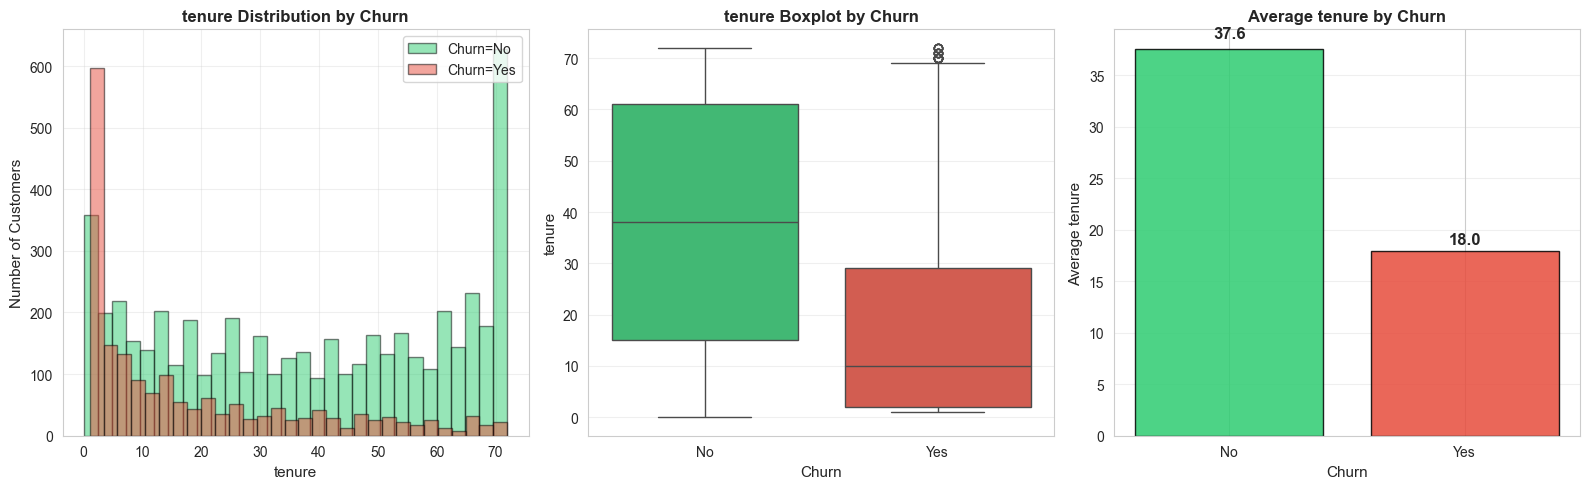


📊 Statistical summary for tenure:
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0

💡 Mean for customers who STAYED:  37.57
💡 Mean for customers who CHURNED: 17.98
📈 Difference: -52.1%


In [22]:
# 🔬 Insight #8: Tenure (months as customer)
plot_numerical_vs_churn('tenure')

Text(0.5, 0, 'Tenure Group')

Text(0, 0.5, 'Number of Customers')

[Text(0, 0, '0-6 mo'),
 Text(1, 0, '7-12 mo'),
 Text(2, 0, '13-24 mo'),
 Text(3, 0, '25-36 mo'),
 Text(4, 0, '37-48 mo'),
 Text(5, 0, '49-60 mo'),
 Text(6, 0, '61+ mo')]

Text(0, 0.5, 'Churn Rate (%)')

Text(0, 53.93720459149224, '52.9%')

...

Text(4, 20.028871391076116, '19.0%')

Text(5, 15.423076923076922, '14.4%')

Text(6, 7.609808102345416, '6.6%')

Text(0.5, 1.0, '🎯 The Tenure-Churn Story: Where Do We Lose Customers?')

C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\942849622.py:54: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\942849622.py:54: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\942849622.py:54: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\942849622.py:55: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig('../reports/figures/04_tenure_danger_zone.png', dpi=150, bbox_inches='tight')
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\942849622.py:55: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.savefig('../reports/figures/04_tenure_danger_zone.png', dpi=150, bbox_inches='tight')
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\94284962

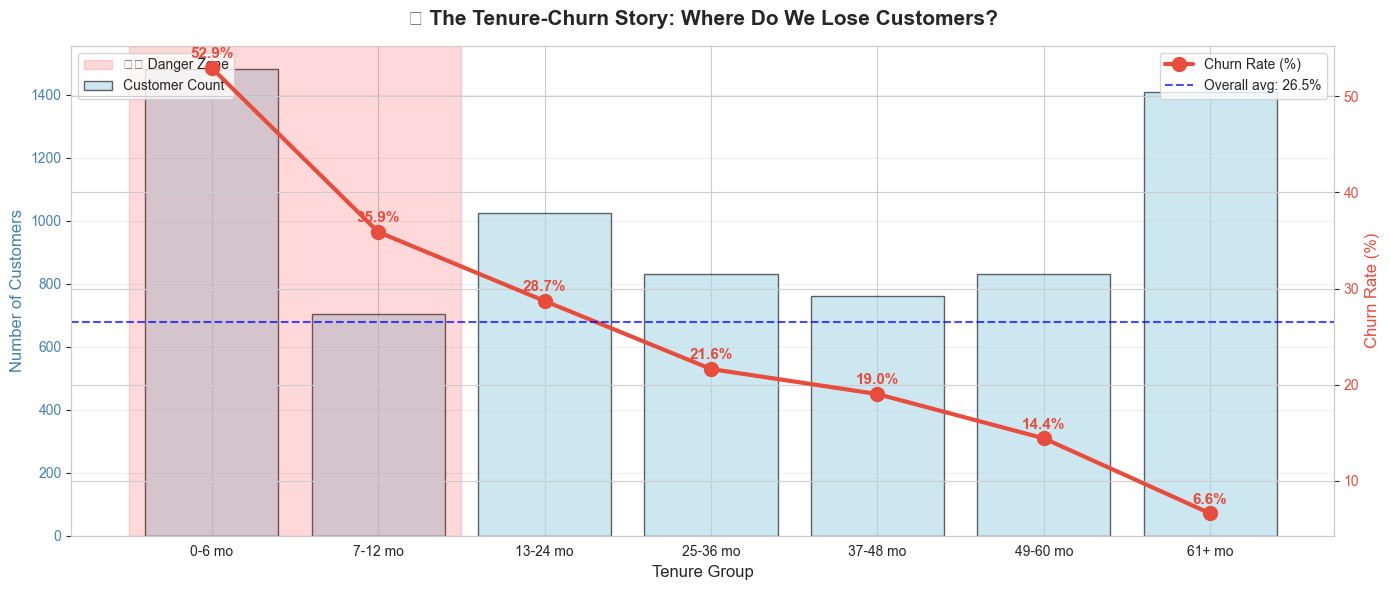


📊 The Customer Lifecycle Story:

🚨 0-6 mo: 52.9% churn rate (1,481 customers)
⚠️ 7-12 mo: 35.9% churn rate (705 customers)
⚠️ 13-24 mo: 28.7% churn rate (1,024 customers)
✅ 25-36 mo: 21.6% churn rate (832 customers)
✅ 37-48 mo: 19.0% churn rate (762 customers)
✅ 49-60 mo: 14.4% churn rate (832 customers)
✅ 61+ mo: 6.6% churn rate (1,407 customers)


In [23]:
# 🔬 Insight #9: Tenure deep dive - bucket analysis
# Create tenure buckets to see the churn rate evolution

bins = [0, 6, 12, 24, 36, 48, 60, 72]
labels = ['0-6 mo', '7-12 mo', '13-24 mo', '25-36 mo', '37-48 mo', '49-60 mo', '61+ mo']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# Calculate churn rate per tenure bucket
churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)

# Calculate customer count per bucket
count_by_tenure = df.groupby('tenure_group', observed=True).size()

# Build the visualization
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart: number of customers per tenure group
bars = ax1.bar(range(len(churn_by_tenure)), count_by_tenure.values, 
                color='lightblue', edgecolor='black', alpha=0.6, label='Customer Count')
ax1.set_xlabel('Tenure Group', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(range(len(churn_by_tenure)))
ax1.set_xticklabels(churn_by_tenure.index, rotation=0)

# Line chart on second y-axis: churn rate
ax2 = ax1.twinx()
ax2.plot(range(len(churn_by_tenure)), churn_by_tenure.values, 
         color='#e74c3c', marker='o', markersize=10, linewidth=3, label='Churn Rate (%)')
ax2.set_ylabel('Churn Rate (%)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Add labels on the line
for i, rate in enumerate(churn_by_tenure.values):
    ax2.text(i, rate + 1, f'{rate:.1f}%', ha='center', fontsize=11, 
             fontweight='bold', color='#e74c3c')

# Add baseline
ax2.axhline(y=26.5, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, 
            label='Overall avg: 26.5%')

# Highlight the danger zone
ax1.axvspan(-0.5, 1.5, alpha=0.15, color='red', label='⚠️ Danger Zone')

ax1.set_title('🎯 The Tenure-Churn Story: Where Do We Lose Customers?', 
              fontsize=15, fontweight='bold', pad=15)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/04_tenure_danger_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# Print insights
print("\n📊 The Customer Lifecycle Story:\n")
for group, rate in churn_by_tenure.items():
    count = count_by_tenure[group]
    if rate > 40:
        emoji = "🚨"
    elif rate > 26.5:
        emoji = "⚠️"
    else:
        emoji = "✅"
    print(f"{emoji} {group}: {rate:.1f}% churn rate ({count:,} customers)")

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\categorical.py:632: FutureWarning

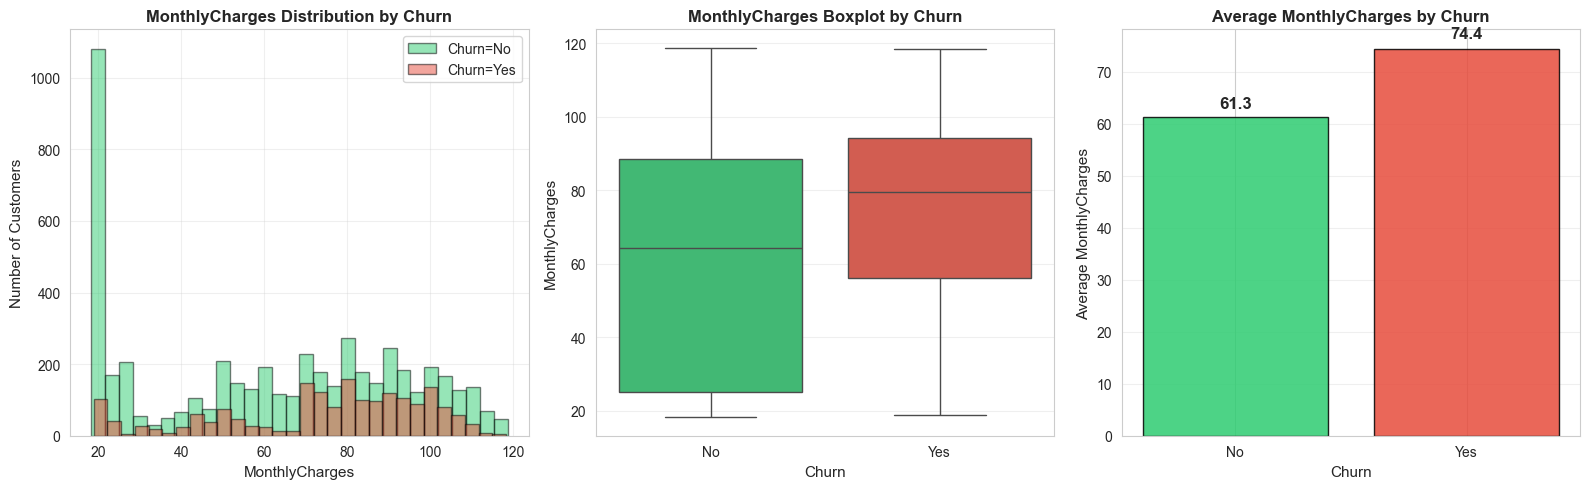


📊 Statistical summary for MonthlyCharges:
        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35

💡 Mean for customers who STAYED:  61.27
💡 Mean for customers who CHURNED: 74.44
📈 Difference: +21.5%


In [24]:
# 🔬 Insight #10: Monthly Charges
plot_numerical_vs_churn('MonthlyCharges')

C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\aleec\anaconda3\envs\churn-env\Lib\site-packages\seaborn\categorical.py:632: FutureWarning

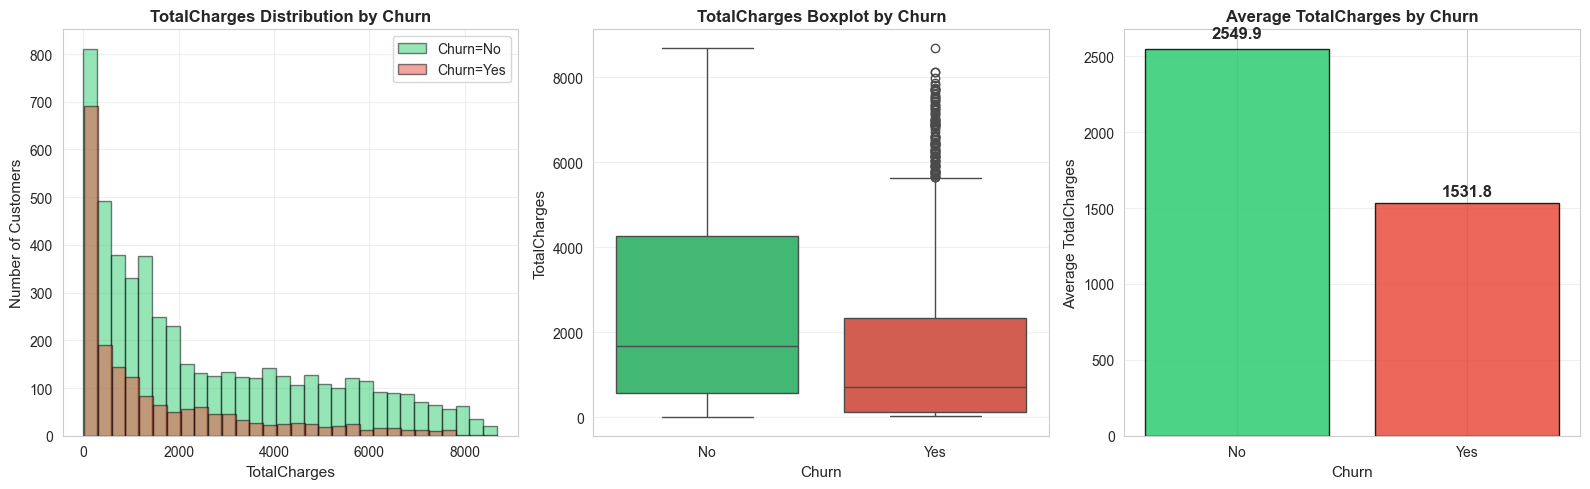


📊 Statistical summary for TotalCharges:
        count     mean      std    min    25%      50%      75%      max
Churn                                                                   
No     5174.0  2549.91  2329.95   0.00  572.9  1679.52  4262.85  8672.45
Yes    1869.0  1531.80  1890.82  18.85  134.5   703.55  2331.30  8684.80

💡 Mean for customers who STAYED:  2549.91
💡 Mean for customers who CHURNED: 1531.80
📈 Difference: -39.9%


In [25]:
# 🔬 Insight #11: Total Charges
plot_numerical_vs_churn('TotalCharges')

Text(0.5, 0, 'Tenure (months)')

Text(0, 0.5, 'Monthly Charges ($)')

Text(0.5, 1.0, '🎯 The Churn Battlefield: Tenure vs Monthly Charges')

Text(8, 105, '🚨 DANGER ZONE\n(High price + Low tenure)')

Text(55, 30, '✅ LOYAL ZONE\n(Long tenure + Low price)')

C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\4039727206.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\4039727206.py:31: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\4039727206.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\4039727206.py:32: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  plt.savefig('../reports/figures/05_tenure_vs_charges.png', dpi=150, bbox_inches='tight')
C:\Users\aleec\AppData\Local\Temp\ipykernel_23956\4039727206.py:32: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from current font.
  plt.savefig('../reports/figures/05_tenure_vs_charges.png', dpi=150, bbox_inches='tight')
C:\Users\aleec\AppDat

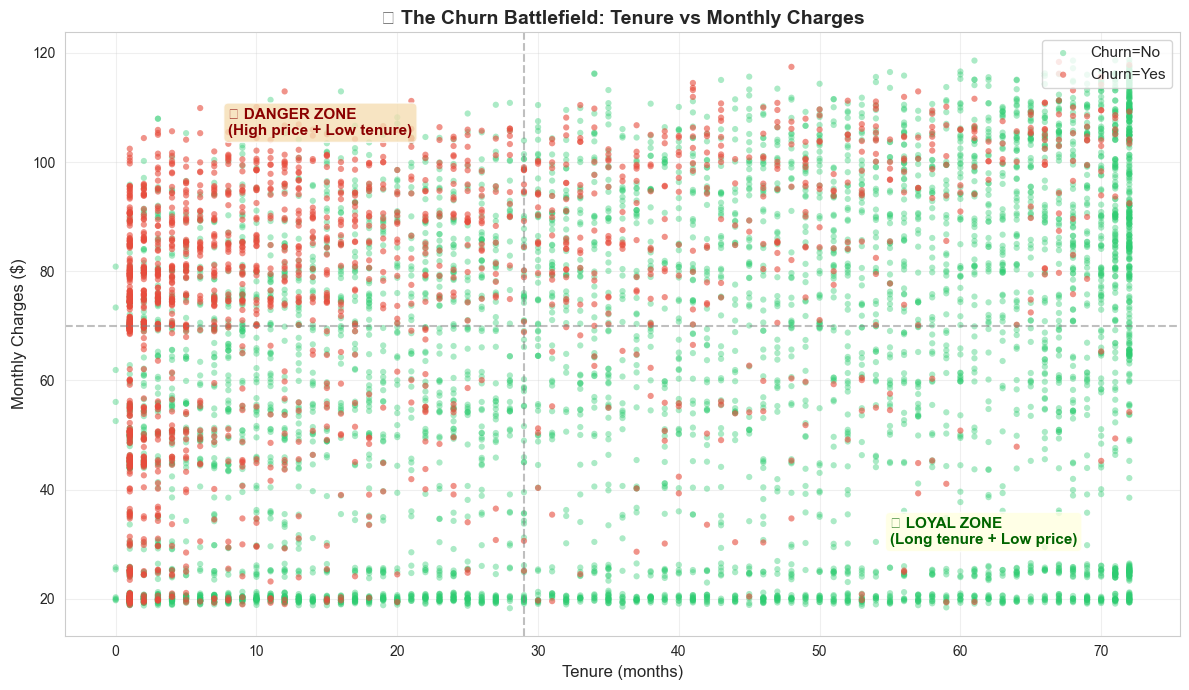

✅ Bivariate analysis saved!


In [26]:
# 🔬 Insight #12: Tenure vs Monthly Charges (with churn coloring)
fig, ax = plt.subplots(figsize=(12, 7))

# Plot stayers and churners with different colors
for status, color, alpha in [('No', '#2ecc71', 0.4), ('Yes', '#e74c3c', 0.6)]:
    subset = df[df['Churn'] == status]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'], 
               c=color, label=f'Churn={status}', alpha=alpha, s=20, edgecolors='none')

ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('🎯 The Churn Battlefield: Tenure vs Monthly Charges', 
             fontsize=14, fontweight='bold')

# Add quadrant lines (median splits)
ax.axvline(x=29, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=70, color='gray', linestyle='--', alpha=0.5)

# Annotate the danger zone
ax.text(8, 105, '🚨 DANGER ZONE\n(High price + Low tenure)', 
        fontsize=11, fontweight='bold', color='darkred',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.text(55, 30, '✅ LOYAL ZONE\n(Long tenure + Low price)', 
        fontsize=11, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/05_tenure_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Bivariate analysis saved!")